## Mutation-Level Comparison Model Workflow

This notebook reuses the mutation-level dataset curation logic from the current paper workflow and swaps in an alternative statistical model.
The 2021 supervised set, temporal reclassification benchmark, and 2023 release-side feature tables are all aligned to the mutation-level formulation.


## 1. Imports and Notebook Setup
This notebook evaluates the non-GAQQ comparison models using the same mutation-level data curation as the main paper workflow.


## Rerun Note

Recommended execution order: run top-to-bottom after a fresh kernel restart. 
These notebooks now use the mutation-level 2021 training set (`370 -> 345`) and the mutation-level 2021→2023 temporal benchmark (`81 -> 62`).

If a later metric cell fails with a missing variable, rerun the current section from its markdown header rather than executing individual cells out of order.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc


## 2. Shared Mutation-Level Data Curation
Here we load the paper-release feature tables, apply the same `Prox_3D` filter as the main notebook, and define helper functions for mutation-level supervised collapse and temporal reclassification.


In [2]:
# Load the paper-release feature tables and define mutation-level helpers
from pathlib import Path

DATA_2021 = Path('/project/pi_annagreen_umass_edu/mahbuba/all_projects/resistance_forecast/paper_release/source_data/derived_features/2021/2021_final_df.csv')
DATA_2023 = Path('/project/pi_annagreen_umass_edu/mahbuba/all_projects/resistance_forecast/paper_release/source_data/derived_features/2023/2023_final_df.csv')

BINARY_MAP = {
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0,
    "5) Not assoc w R": 0,
}

CONFIDENCE_PRIORITY = {
    '1) Assoc w R': 0,
    '2) Assoc w R - Interim': 1,
    '4) Not assoc w R - Interim': 2,
    '5) Not assoc w R': 3,
    '3) Uncertain significance': 4,
}


def load_release_features(path):
    df = pd.read_csv(path).copy()
    rename_map = {
        'mutation_oneletter': 'one_letter_mutation',
        'Rosetta_fa_atr': 'fa_atr',
        'Rosetta_fa_rep': 'fa_rep',
        'Rosetta_fa_sol': 'fa_sol',
        'Rosetta_fa_elec': 'fa_elec',
        'Rosetta_fa_dun': 'fa_dun',
        'Rosetta_ddG': 'thermostability',
        'Prox_3D_zeroed': 'Proximity_to_R_Conferring',
        'LLR_score': 'llr_score',
        'freq_variant': 'frequency',
        'AAIndex_mut1': 'mut_AAIndex1',
        'AAIndex_mut2': 'mut_AAIndex2',
        'AAIndex_mut3': 'mut_AAIndex3',
        'AAIndex_mut4': 'mut_AAIndex4',
        'AAIndex_mut5': 'mut_AAIndex5',
        'AAIndex_mut6': 'mut_AAIndex6',
        'AAIndex_mut7': 'mut_AAIndex7',
        'AAIndex_mut8': 'mut_AAIndex8',
    }
    df = df.rename(columns=rename_map)
    return df


def collapse_supervised_mutation_level(df):
    labeled = df[df['confidence'] != '3) Uncertain significance'].copy()
    labeled['_binary_confidence'] = labeled['confidence'].map(BINARY_MAP)
    labeled = labeled[labeled['_binary_confidence'].notna()].copy()
    pre_n = labeled.shape[0]
    labeled = labeled.drop_duplicates(subset=['gene', 'one_letter_mutation', '_binary_confidence']).copy()
    print(f'Collapsed supervised labeled set: {pre_n} -> {labeled.shape[0]} rows')
    return labeled.drop(columns=['_binary_confidence'])


def collapse_confidence_to_mutation_level(df, confidence_col='confidence'):
    rows = []
    for (gene, mut), sub in df.groupby(['gene', 'one_letter_mutation'], dropna=False):
        confs = [c for c in sub[confidence_col].dropna().tolist()]
        non_uncertain = [c for c in confs if c != '3) Uncertain significance']
        pool = non_uncertain if non_uncertain else confs
        chosen = sorted(pool, key=lambda c: CONFIDENCE_PRIORITY.get(c, 999))[0] if pool else np.nan
        first = sub.iloc[0].copy()
        first[confidence_col] = chosen
        rows.append(first)
    return pd.DataFrame(rows).reset_index(drop=True)


def merge_catalogs_mutation_level(df_2021, df_2023):
    df_2021_mut = collapse_confidence_to_mutation_level(df_2021, 'confidence')
    df_2023_mut = collapse_confidence_to_mutation_level(df_2023, 'confidence')
    merged_df = pd.merge(
        df_2021_mut,
        df_2023_mut,
        on=['gene', 'one_letter_mutation'],
        suffixes=('_2021', '_2023')
    )
    return merged_df.drop_duplicates()


catalog_data = load_release_features(DATA_2021)
catalog_data = catalog_data.drop_duplicates()
catalog_data = catalog_data[catalog_data['Prox_3D'].notna()].copy()
print(f'Catalog rows after Prox_3D filter: {catalog_data.shape[0]}')


Catalog rows after Prox_3D filter: 4248


In [3]:
catalog_data.shape


(4248, 50)

In [4]:
catalog_data = catalog_data.drop_duplicates()


In [5]:
print(catalog_data.shape)


(4248, 50)


In [6]:
catalog_data['confidence'].value_counts()


confidence
3) Uncertain significance     3866
2) Assoc w R - Interim         158
1) Assoc w R                   154
5) Not assoc w R                37
4) Not assoc w R - Interim      21
combo                           12
Name: count, dtype: int64

In [7]:
catalog_data.columns


Index(['gene', 'drug', 'confidence', 'phenotype', 'one_letter_mutation',
       'mutation_wt', 'mutation_pos', 'mutation_mut', 'frequency', 'fa_atr',
       'fa_rep', 'fa_sol', 'fa_elec', 'fa_dun', 'thermostability', 'DeltaZ',
       'Prox_WHO_Adjusted_Pos', 'Prox_1D', 'Prox_1D_nearest', 'Prox_3D',
       'Prox_3D_nearest', 'Proximity_to_R_Conferring', 'llr_score',
       'LLR_dim33', 'LLR_dim46', 'LLR_dim62', 'LLR_dim70', 'LLR_dim124',
       'LLR_dim192', 'LLR_dim207', 'LLR_dim258', 'LLR_dim267', 'LLR_dim315',
       'AAIndex_delta1', 'AAIndex_delta2', 'AAIndex_delta3', 'AAIndex_delta4',
       'AAIndex_delta5', 'AAIndex_delta6', 'AAIndex_delta7', 'AAIndex_delta8',
       'mut_AAIndex1', 'mut_AAIndex2', 'mut_AAIndex3', 'mut_AAIndex4',
       'mut_AAIndex5', 'mut_AAIndex6', 'mut_AAIndex7', 'mut_AAIndex8',
       'mutation'],
      dtype='object')

## 3. Supervised Training Dataset
These cells construct the 2021 labeled mutation-level training set and prepare the features used by the comparison models.


In [8]:
# Count the number of NaN rows in the 'Proximity_to_R_Conferring' column for each unique gene
nan_frequency_count = catalog_data.groupby('gene')['llr_score'].apply(lambda x: x.isna().sum())

# Display the result
print(nan_frequency_count)


gene
ddn     0
embB    0
ethA    0
gid     0
gyrA    0
gyrB    0
inhA    0
katG    0
pncA    0
rplC    0
rpoB    0
rpsL    0
tlyA    0
Name: llr_score, dtype: int64


In [9]:
# Filter out category 3 entries and collapse to mutation level
label_data = collapse_supervised_mutation_level(catalog_data)


Collapsed supervised labeled set: 370 -> 345 rows


In [10]:
np.unique(label_data['confidence'].value_counts())


array([ 19,  28, 145, 153])

In [11]:
# Build comparison-model features by dropping metadata columns, mirroring the main mutation-level notebook
base_drop_cols = {
    'mutation_wt', 'mutation_pos', 'mutation_mut',
    'drug', 'one_letter_mutation',
    'DeltaZ', 'frequency',
    'Prox_WHO_Adjusted_Pos',
    'Prox_1D', 'Prox_1D_nearest',
    'Prox_3D', 'Prox_3D_nearest',
    'llr_score', 'mutation',
}
base_drop_cols.update({c for c in label_data.columns if c.startswith('AAIndex_delta')})
meta_cols = {'confidence', 'phenotype', 'gene'}

candidate_numeric_columns = [
    c for c in label_data.columns
    if c not in base_drop_cols and c not in meta_cols and pd.api.types.is_numeric_dtype(label_data[c])
]

# Keep the comparison model aligned to the paper notebook feature family set.
allowed_features = {
    'fa_atr', 'fa_rep', 'fa_sol', 'fa_elec', 'fa_dun', 'thermostability',
    'Proximity_to_R_Conferring',
    'mut_AAIndex1', 'mut_AAIndex2', 'mut_AAIndex3', 'mut_AAIndex4',
    'mut_AAIndex5', 'mut_AAIndex6', 'mut_AAIndex7', 'mut_AAIndex8',
    'LLR_dim33', 'LLR_dim46', 'LLR_dim62', 'LLR_dim70', 'LLR_dim124',
    'LLR_dim192', 'LLR_dim207', 'LLR_dim258', 'LLR_dim267', 'LLR_dim315'
}

numeric_columns = [c for c in candidate_numeric_columns if c in allowed_features]
print('Numeric columns:', numeric_columns)
print('Feature count:', len(numeric_columns))
label_data[numeric_columns] = label_data[numeric_columns].fillna(0)


Numeric columns: ['fa_atr', 'fa_rep', 'fa_sol', 'fa_elec', 'fa_dun', 'thermostability', 'Proximity_to_R_Conferring', 'LLR_dim33', 'LLR_dim46', 'LLR_dim62', 'LLR_dim70', 'LLR_dim124', 'LLR_dim192', 'LLR_dim207', 'LLR_dim258', 'LLR_dim267', 'LLR_dim315', 'mut_AAIndex1', 'mut_AAIndex2', 'mut_AAIndex3', 'mut_AAIndex4', 'mut_AAIndex5', 'mut_AAIndex6', 'mut_AAIndex7', 'mut_AAIndex8']
Feature count: 25


In [12]:
len(numeric_columns)


25

## 4. Holdout Split and Model Fitting
This section standardizes the features, performs the holdout split, and fits the GAM / MARS-style comparison models.


In [13]:
# Extract the feature matrix and target vector
X_label = label_data[numeric_columns]
y_label= label_data['confidence']


In [14]:
print(X_label.shape, y_label.shape)


(345, 25) (345,)


In [15]:
np.unique(y_label)


array(['1) Assoc w R', '2) Assoc w R - Interim',
       '4) Not assoc w R - Interim', '5) Not assoc w R'], dtype=object)

In [16]:
# Convert the target variable to numeric labels

y_label = y_label.map({
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0, #replace 2 into 1 since the expected domain for gam is 0 or 1
    "5) Not assoc w R": 0
})


In [17]:
y_label.value_counts()


confidence
1    298
0     47
Name: count, dtype: int64

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)


In [19]:
# Split the data into training and testing sets
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y_label, test_size=0.3, random_state=42)


In [20]:
X_test_split.shape


(104, 25)

In [26]:
import scipy.sparse as sp

for cls_name in ['csr_matrix', 'csc_matrix', 'csr_array', 'csc_array']:
    cls = getattr(sp, cls_name, None)
    if cls is not None and not hasattr(cls, 'A'):
        cls.A = property(lambda self: self.toarray())


In [27]:
# Train GAM on the mutation-level 2021 holdout split
from pygam import LogisticGAM

# Directly train the GAM without lambda grid search(GCV instead)
gam = LogisticGAM().fit(X_train_split, y_train_split)
gam_clf = LogisticGAM().fit(X_train_split, y_train_split)
y_test_proba = gam_clf.predict_proba(X_test_split)

custom_threshold = 0.5
y_test_pred = (y_test_proba >= custom_threshold).astype(int)
print("Predicted Classes:", y_test_pred[:10]) 
accuracy = accuracy_score(y_test_split, y_test_pred)
print(accuracy)


/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2


Predicted Classes: [1 1 1 1 1 1 1 1 1 1]
0.8557692307692307


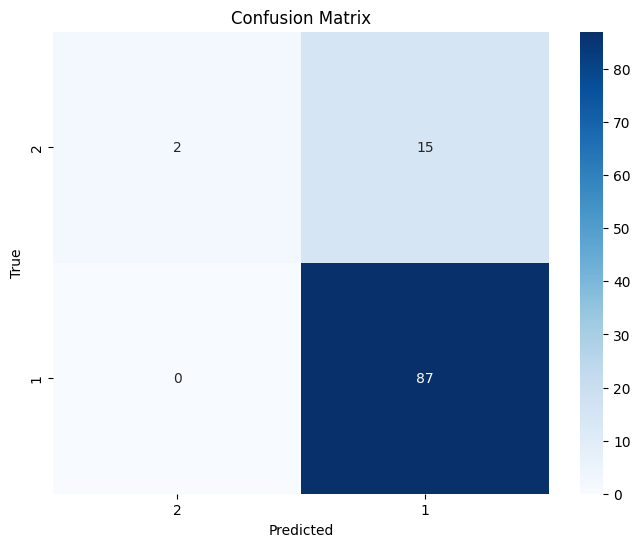

In [28]:
cm = confusion_matrix(y_test_split, y_test_pred )
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [29]:
 # accuracy
accuracy = accuracy_score(y_test_split, y_test_pred )
print("\nAccuracy:", accuracy)

# Classification
print("\nClassification Report:")
print(classification_report(y_test_split, y_test_pred )) 



Accuracy: 0.8557692307692307

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.12      0.21        17
           1       0.85      1.00      0.92        87

    accuracy                           0.86       104
   macro avg       0.93      0.56      0.57       104
weighted avg       0.88      0.86      0.80       104



y_prob_split.shape: (104, 2)
Unique classes: [0, 1]
Number of prediction columns in y_prob_split: 2
Class 0, AUC = 0.86
Class 1, AUC = 0.86


<function matplotlib.pyplot.show(close=None, block=None)>

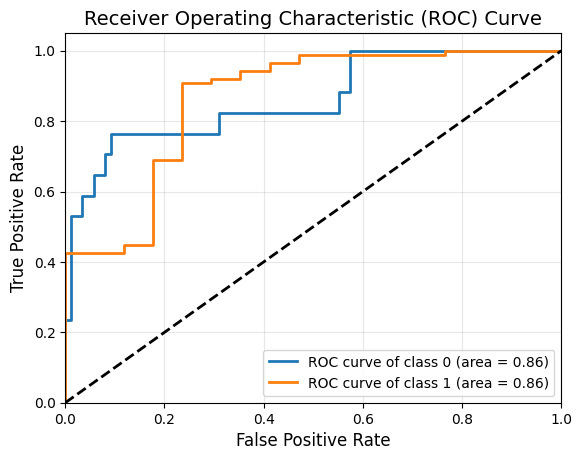

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Get the predicted probability
y_prob_split = gam_clf.predict_proba(X_test_split)

# 2. If it is a binary classification and only one column is returned, expand it to two columns [p(0), p(1)] = [1 - p, p]
if y_prob_split.ndim == 1:
    y_prob_split = np.column_stack([1 - y_prob_split, y_prob_split])
elif y_prob_split.shape[1] == 1:
    # If the shape is (n_samples,1), we can also squeeze it again
    y_prob_split = y_prob_split.squeeze(axis=1)
    y_prob_split = np.column_stack([1 - y_prob_split, y_prob_split])

print("y_prob_split.shape:", y_prob_split.shape)

# 3. Get the categories in the training set and sort them
unique_classes = sorted(np.unique(y_train_split))
print("Unique classes:", unique_classes)
print("Number of prediction columns in y_prob_split:", y_prob_split.shape[1])

# 4.Create a category -> column index mapping
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}

# 5. cauculate  ROC
fpr = {}
tpr = {}
roc_auc = {}

for cls in unique_classes:
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(f"Class {cls}, AUC = {roc_auc[cls]:.2f}")

# 6. plot
plt.figure()
for cls in unique_classes:
    plt.plot(fpr[cls], tpr[cls], lw=2, label=f"ROC curve of class {cls} (area = {roc_auc[cls]:0.2f})")
    
# Plot the diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2)
# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show


In [34]:
gam.summary()


LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     21.1379
Link Function:                        LogitLink Log Likelihood:                                   -57.1693
Number of Samples:                          241 AIC:                                              156.6144
                                                AICc:                                             161.3167
                                                UBRE:                                                 2.72
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.3687
Feature Function                  Lam

/scratch/login/ipykernel_3368592/869333826.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


[0.0, 2.996375370045712e-10, 0.0, 0.0, 0.0, 4.20462387129561e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.01192776953395791, 0.0, 3.1650523539150655e-05, 0.0, 0.057404517280878475, 0.21724716788096954, 0.0, 0.0]
['fa_atr', 'fa_rep', 'fa_sol', 'fa_elec', 'fa_dun', 'thermostability', 'Proximity_to_R_Conferring', 'LLR_dim33', 'LLR_dim46', 'LLR_dim62', 'LLR_dim70', 'LLR_dim124', 'LLR_dim192', 'LLR_dim207', 'LLR_dim258', 'LLR_dim267', 'LLR_dim315', 'mut_AAIndex1', 'mut_AAIndex2', 'mut_AAIndex3', 'mut_AAIndex4', 'mut_AAIndex5', 'mut_AAIndex6', 'mut_AAIndex7', 'mut_AAIndex8']


/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


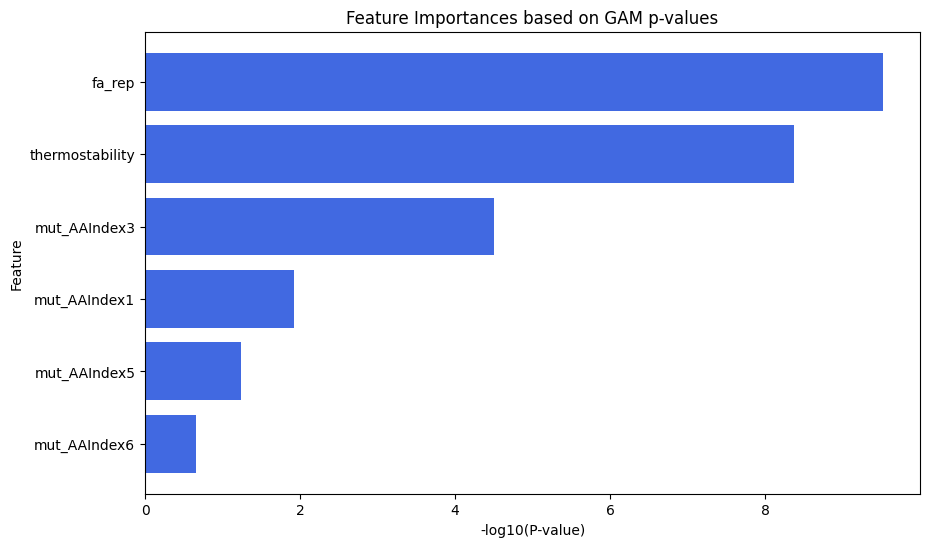

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = numeric_columns

p_values = gam.statistics_['p_values']
p_values = p_values[:-1]  # remove intercept

print(p_values)
print(feature_names)

df_importance = pd.DataFrame({
    "Feature": feature_names,
    "P-value": p_values
})

df_importance = df_importance.sort_values(by="P-value", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_importance["Feature"], -np.log10(df_importance["P-value"]), color="royalblue")
plt.xlabel("-log10(P-value)")
plt.ylabel("Feature")
plt.title("Feature Importances based on GAM p-values")
plt.gca().invert_yaxis()
plt.show()


In [37]:
#Multivariate Adaptive Regression Splines (MARS)
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

# activate transform between pandas and R  
pandas2ri.activate()

# import r package 
base = importr('base')
utils = importr('utils')
earth = importr('earth')


In [38]:
# Train MARS on the mutation-level 2021 holdout split
# try several degree for MARS
mars_model = earth.earth(X_train_split, y_train_split ,degree =4) #when degree=4 ..., it will have high acc
#when degree=1,2,3 acc=89%
#It is best not to have a high degree, as a high degree will lead to a lack of interpretability.

# use predict() function in R to predict
predict = ro.r['predict']  # loading predict() from R
y_pred_r = predict(mars_model, X_test_split, type = "class")  # prediction

# transform matrix(in R) to numpy 
y_test_pred = np.array(y_pred_r) 
 
# Calculate the accuracy
accuracy_score(y_test_split, y_test_pred)
print(accuracy_score(y_test_split, y_test_pred))


0.9038461538461539


In [39]:
summary = ro.r['summary']
model_summary = summary(mars_model)
print(model_summary)


Call: earth(x=matrix[241,25], y=c(0,1,1,1,1,1,1...), degree=4)

                                                                        coefficients
(Intercept)                                                                0.9845580
h(x7-0.706564)                                                            -1.4150352
h(x7-1.28304)                                                              1.3597924
h(x5- -1.30328) * h(0.137554-x6)                                          -0.7898053
h(x16- -0.25453) * h(x23- -1.35189)                                        0.0261166
h(-1.30328-x5) * x10 * x17                                                 0.6570300
h(x5- -1.30328) * h(0.137554-x6) * h(x7- -0.215856)                        0.2016630
h(x5- -1.30328) * h(0.137554-x6) * h(-0.215856-x7)                         5.7988295
h(x5- -1.30328) * h(0.137554-x6) * h(x9- -0.0502925)                       0.1967660
h(x5- -1.30328) * h(0.137554-x6) * h(-0.0502925-x9)                        0.1643748
h

              precision    recall  f1-score   support

           0       0.77      0.59      0.67        17
           1       0.92      0.97      0.94        87

    accuracy                           0.90       104
   macro avg       0.85      0.78      0.81       104
weighted avg       0.90      0.90      0.90       104



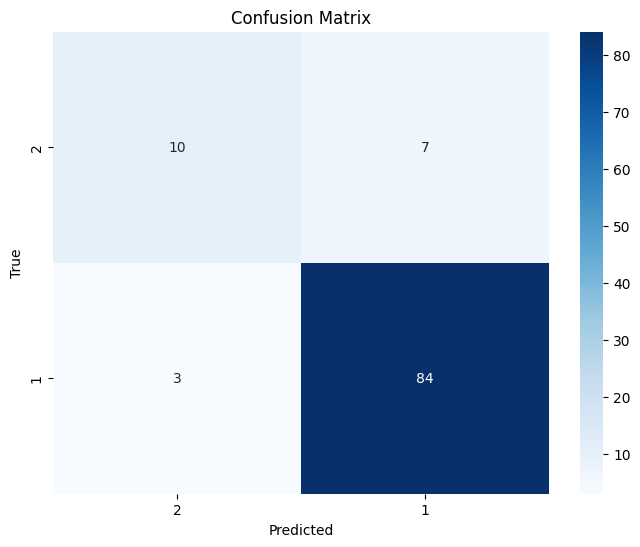

In [40]:
print(classification_report(y_test_split, y_test_pred))
cm = confusion_matrix(y_test_split, y_test_pred )
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Unique classes: [0, 1]
Class 0 AUC: 0.88
Class 1 AUC: 0.88


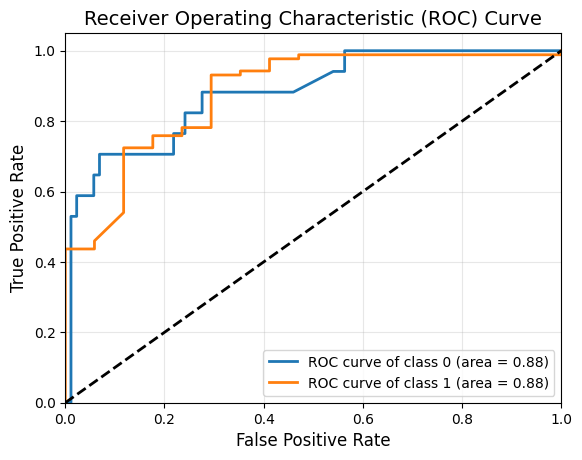

In [41]:
# use the predic function in R on the mars model
predict = ro.r['predict'] # use predict function in R
# use mars to predict
y_pred_response = np.array(predict(mars_model, X_test_split, type="response"))
 
y_prob_split = np.column_stack([1 - y_pred_response, y_pred_response])

# transform into numpy
y_pred_r = predict(mars_model, X_test_split, type="class")  
 

unique_classes = sorted(np.unique(y_train_split))
print("Unique classes:", unique_classes)

class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}
fpr = {}
tpr = {}
roc_auc = {}

# calculate roc and auc for each category  
for cls in unique_classes:
    idx = class_to_index[cls]
    fpr[cls], tpr[cls], _ = roc_curve(y_test_split == cls, y_prob_split[:, idx])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])
    print(f"Class {cls} AUC: {roc_auc[cls]:.2f}")

# roc figure
plt.figure()

for cls in unique_classes:
    plt.plot(fpr[cls], tpr[cls], lw=2, label=f"ROC curve of class {cls} (area = {roc_auc[cls]:0.2f})")

 
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()


## 5. Temporal Reclassification Benchmark
We collapse 2021 and 2023 confidence calls to mutation level, merge the two catalogues, and measure how many mutations stayed uncertain versus moved out of Category 3.


In [42]:
from IPython.display import display
import pandas as pd

# Load the 2021 and 2023 datasets
file_2021 = DATA_2021
file_2023 = DATA_2023

df_2021 = load_release_features(file_2021)
df_2023 = load_release_features(file_2023)
df_2021 = df_2021[df_2021['Prox_3D'].notna()].copy()
df_2023 = df_2023[df_2023['Prox_3D'].notna()].copy()


In [43]:
# Collapse both years to mutation level, then merge on gene + mutation
merged_df = merge_catalogs_mutation_level(df_2021, df_2023)


In [44]:
# Filter rows where confidence remained unchanged in category 3
unchanged_category_3 = merged_df[
    (merged_df['confidence_2021'] == "3) Uncertain significance") &
    (merged_df['confidence_2023'] == "3) Uncertain significance")
]
unchanged_category_3 = unchanged_category_3.drop_duplicates()

# Count the number of positions where the confidence remained unchanged
num_unchanged = unchanged_category_3.shape[0]

print(f"Number of positions where confidence remained unchanged in category 3: {num_unchanged}")

# Optionally, preview the unchanged rows
display(unchanged_category_3[['gene', 'one_letter_mutation', 'confidence_2021', 'confidence_2023']])


Number of positions where confidence remained unchanged in category 3: 3114


,gene,one_letter_mutation,confidence_2021,confidence_2023
0,ddn,A120S,3) Uncertain significance,3) Uncertain significance
1,ddn,E83D,3) Uncertain significance,3) Uncertain significance
2,ddn,F66S,3) Uncertain significance,3) Uncertain significance
3,ddn,G34E,3) Uncertain significance,3) Uncertain significance
4,ddn,G34R,3) Uncertain significance,3) Uncertain significance
...,...,...,...,...
3515,tlyA,V178A,3) Uncertain significance,3) Uncertain significance
3516,tlyA,V198G,3) Uncertain significance,3) Uncertain significance
3517,tlyA,V32L,3) Uncertain significance,3) Uncertain significance
3518,tlyA,V7F,3) Uncertain significance,3) Uncertain significance


In [45]:
# Exclude rows where confidence is "3) Uncertain significance" in both files
filtered_df = merged_df[
    ~((merged_df['confidence_2021'] == "3) Uncertain significance") &
      (merged_df['confidence_2023'] == "3) Uncertain significance"))
]

# Identify rows where confidence values differ between 2021 and 2023
updated_confidence = filtered_df[
    filtered_df['confidence_2021'] != filtered_df['confidence_2023']
]


In [46]:
print(merged_df.shape,filtered_df.shape,updated_confidence.shape)


(3520, 100) (406, 100) (116, 100)


In [47]:
filtered_df=filtered_df.drop_duplicates()


In [48]:
filtered_df['confidence_2021'].value_counts()


confidence_2021
2) Assoc w R - Interim        149
1) Assoc w R                  144
3) Uncertain significance      62
5) Not assoc w R               28
4) Not assoc w R - Interim     18
combo                           5
Name: count, dtype: int64

In [49]:
filtered_df['confidence_2023'].value_counts()


confidence_2023
1) Assoc w R                  172
2) Assoc w R - Interim        168
5) Not assoc w R               27
4) Not assoc w R - Interim     20
3) Uncertain significance      19
Name: count, dtype: int64

In [50]:
# Check for rows where confidence is 3 in both 2021 and 2023
confidence_3_in_both = filtered_df[
    (filtered_df['confidence_2021'] == "3) Uncertain significance") &
    (filtered_df['confidence_2023'] == "3) Uncertain significance")
]

# Display the result
print(f"Number of rows with confidence 3 in both 2021 and 2023: {confidence_3_in_both.shape[0]}")
print(confidence_3_in_both)


Number of rows with confidence 3 in both 2021 and 2023: 0
Empty DataFrame
Columns: [gene, drug_2021, confidence_2021, phenotype_2021, one_letter_mutation, mutation_wt_2021, mutation_pos_2021, mutation_mut_2021, frequency_2021, fa_atr_2021, fa_rep_2021, fa_sol_2021, fa_elec_2021, fa_dun_2021, thermostability_2021, DeltaZ_2021, Prox_WHO_Adjusted_Pos_2021, Prox_1D_2021, Prox_1D_nearest_2021, Prox_3D_2021, Prox_3D_nearest_2021, Proximity_to_R_Conferring_2021, llr_score_2021, LLR_dim33_2021, LLR_dim46_2021, LLR_dim62_2021, LLR_dim70_2021, LLR_dim124_2021, LLR_dim192_2021, LLR_dim207_2021, LLR_dim258_2021, LLR_dim267_2021, LLR_dim315, AAIndex_delta1_2021, AAIndex_delta2_2021, AAIndex_delta3_2021, AAIndex_delta4_2021, AAIndex_delta5_2021, AAIndex_delta6_2021, AAIndex_delta7_2021, AAIndex_delta8_2021, mut_AAIndex1_2021, mut_AAIndex2_2021, mut_AAIndex3_2021, mut_AAIndex4_2021, mut_AAIndex5_2021, mut_AAIndex6_2021, mut_AAIndex7_2021, mut_AAIndex8_2021, mutation, drug_2023, confidence_2023, pheno

In [51]:
# Filter for confidence_2021 == "3) Uncertain significance" that changed to other categories
confidence_3_changed = filtered_df[
    (filtered_df['confidence_2021'] == "3) Uncertain significance") &
    (filtered_df['confidence_2023'] != "3) Uncertain significance")
]
confidence_3_changed = confidence_3_changed.drop_duplicates(subset=['gene', 'one_letter_mutation','confidence_2021','confidence_2023'])
# Count value occurrences in confidence_2023
changed_counts = confidence_3_changed['confidence_2023'].value_counts()

# Display the result
print(f"Number of mutations with confidence 3 in 2021 that changed to other categories in 2023: {confidence_3_changed.shape[0]}")
print("Value counts of the changed categories in 2023:")
print(changed_counts)


Number of mutations with confidence 3 in 2021 that changed to other categories in 2023: 62
Value counts of the changed categories in 2023:
confidence_2023
2) Assoc w R - Interim        44
1) Assoc w R                  13
4) Not assoc w R - Interim     4
5) Not assoc w R               1
Name: count, dtype: int64


In [52]:
confidence_3_changed


,gene,drug_2021,confidence_2021,phenotype_2021,one_letter_mutation,mutation_wt_2021,mutation_pos_2021,mutation_mut_2021,frequency_2021,fa_atr_2021,...,mut_AAIndex2_2023,mut_AAIndex3_2023,mut_AAIndex4_2023,mut_AAIndex5_2023,mut_AAIndex6_2023,mut_AAIndex7_2023,mut_AAIndex8_2023,mutation_x,mutation_y,effect
639,ethA,ETH,3) Uncertain significance,Unknown,C403Y,C,403,Y,1.000000,-13.353,...,-3.044647,-12.933385,-1.199468,-7.665342,0.789193,5.025134,-0.269362,C403Y,p.Cys403Tyr,missense_variant
790,ethA,ETH,3) Uncertain significance,Unknown,L35R,L,35,R,0.636364,-2.723,...,-15.801100,-1.267952,0.054632,-8.122787,-8.346795,-4.802642,-5.875155,L35R,p.Leu35Arg,missense_variant
823,ethA,ETH,3) Uncertain significance,Unknown,N379D,N,379,D,0.245283,1.635,...,-3.041215,-0.074920,-1.685450,5.738219,5.063792,9.413392,-2.168806,N379D,p.Asn379Asp,missense_variant
952,ethA,ETH,3) Uncertain significance,Unknown,V202G,V,202,G,1.000000,9.436,...,21.629177,3.123584,-7.335674,-9.426146,8.832837,-4.847755,-3.544305,V202G,p.Val202Gly,missense_variant
1042,gid,STM,3) Uncertain significance,Unknown,A200E,A,200,E,0.600000,-5.963,...,-11.911348,10.555523,4.395205,7.926744,4.113788,4.766319,-3.686369,A200E,p.Ala200Glu,missense_variant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2802,pncA,PZA,3) Uncertain significance,Unknown,V163A,V,163,A,0.000000,1.898,...,5.425814,17.016745,2.204214,2.819659,3.031398,-3.773258,-0.451976,V163A,p.Val163Ala,missense_variant
2816,pncA,PZA,3) Uncertain significance,Unknown,V7F,V,7,F,1.000000,-6.495,...,-0.372797,-3.945659,1.698545,-1.957060,4.111803,1.089936,2.301924,V7F,p.Val7Phe,missense_variant
2820,pncA,PZA,3) Uncertain significance,Unknown,V93A,V,93,A,0.333333,4.392,...,5.425814,17.016745,2.204214,2.819659,3.031398,-3.773258,-0.451976,V93A,p.Val93Ala,missense_variant
2827,pncA,PZA,3) Uncertain significance,Unknown,W68L,W,68,L,1.000000,7.831,...,3.086893,11.307291,6.859719,-2.107819,2.222849,-0.398988,0.928746,W68L,p.Trp68Leu,missense_variant


In [53]:
print(confidence_3_changed['confidence_2021'].unique())
print(confidence_3_changed['confidence_2023'].unique())


['3) Uncertain significance']
['2) Assoc w R - Interim' '1) Assoc w R' '5) Not assoc w R'
 '4) Not assoc w R - Interim']


## 6. Temporal Evaluation Set Construction
`category_3_data` is the mutation-level evaluation set: it contains only 2021 uncertain mutations that were later reclassified in 2023. This should have 62 rows in the current mutation-level workflow.


In [54]:
# Convert the target var 
 

mapping = {
    "1) Assoc w R": 1,
    "2) Assoc w R - Interim": 1,
    "4) Not assoc w R - Interim": 0,
    "5) Not assoc w R": 0,
}

confidence_3_changed['confidence_2023'] = confidence_3_changed['confidence_2023'].map(mapping)

print(confidence_3_changed[['confidence_2021', 'confidence_2023']])
print(confidence_3_changed['confidence_2023'].unique())


                confidence_2021  confidence_2023
639   3) Uncertain significance                1
790   3) Uncertain significance                1
823   3) Uncertain significance                1
952   3) Uncertain significance                1
1042  3) Uncertain significance                1
...                         ...              ...
2802  3) Uncertain significance                1
2816  3) Uncertain significance                1
2820  3) Uncertain significance                1
2827  3) Uncertain significance                1
2837  3) Uncertain significance                1

[62 rows x 2 columns]
[1 0]


In [55]:
# Build the mutation-level temporal evaluation set from 2021 uncertain mutations reclassified in 2023
selected_positions = confidence_3_changed[
    ['gene', 'one_letter_mutation', 'confidence_2023']
].drop_duplicates()

category_3_data = catalog_data[
    catalog_data['confidence'] == "3) Uncertain significance"
].copy()

category_3_data = category_3_data.drop_duplicates(
    subset=['gene', 'one_letter_mutation']
)

category_3_data = category_3_data.merge(
    selected_positions,
    on=['gene', 'one_letter_mutation'],
    how='inner'
)

print("category_3_data shape:", category_3_data.shape)


category_3_data shape: (62, 51)


In [56]:
print(confidence_3_changed.shape)
print(category_3_data.shape)


(62, 100)
(62, 51)


In [57]:
# Step 3: Prepare data for mutation-level temporal prediction
category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
X_category_3 = category_3_data[numeric_columns]
y_true_cat3 = category_3_data['confidence_2023'].to_numpy()
print(X_category_3)
print('Temporal evaluation set size:', len(y_true_cat3))


    fa_atr    fa_rep  fa_sol  fa_elec  fa_dun  thermostability  \
0   -2.723  20.85000   8.220    2.912   2.982        32.898930   
1    9.436  -1.36400   2.573    0.185  -0.114        14.100156   
2    1.635  -0.10500   2.636    0.120  -0.281         6.167893   
3  -13.353  50.00000   8.444   -0.021   4.988        50.000000   
4    3.873  -1.64100  -0.296    2.900   0.527         6.360261   
..     ...       ...     ...      ...     ...              ...   
57   2.386   2.50200  -0.346    0.028   2.233         7.673205   
58   4.577   0.06000  -3.106    2.080  -0.386         5.972033   
59   1.898  -0.14200  -0.296    0.115   0.025         0.657171   
60   2.792  45.97100  -1.253   -0.681   0.313        47.527063   
61  -3.226  41.33245   9.354   -0.898   5.179        43.934364   

    Proximity_to_R_Conferring  LLR_dim33  LLR_dim46  LLR_dim62  ...  \
0                    2.803725   0.113908   0.210244  -0.154033  ...   
1                    9.914465  -0.000397   0.004746  -0.125409  .

In [66]:
# Predict on the mutation-level temporal evaluation set with GAM
y_prob_cat3_gam = gam_clf.predict_proba(X_category_3)
custom_threshold = 0.5
y_pred_cat3_gam = (y_prob_cat3_gam >= custom_threshold).astype(int)
print(y_pred_cat3_gam)
print('GAM temporal prediction size:', len(y_pred_cat3_gam))
assert len(y_true_cat3) == len(y_pred_cat3_gam), 'GAM temporal length mismatch'


[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
GAM temporal prediction size: 62


In [71]:
print(classification_report(y_true_cat3, y_pred_cat3_gam))


              precision    recall  f1-score   support

           0       0.05      0.60      0.09         5
           1       0.33      0.02      0.03        57

    accuracy                           0.06        62
   macro avg       0.19      0.31      0.06        62
weighted avg       0.31      0.06      0.04        62



Unique classes: [0, 1]
Number of prediction columns in y_prob_cat3_gam: 2
Class 0, AUC = 0.17
Class 1, AUC = 0.17


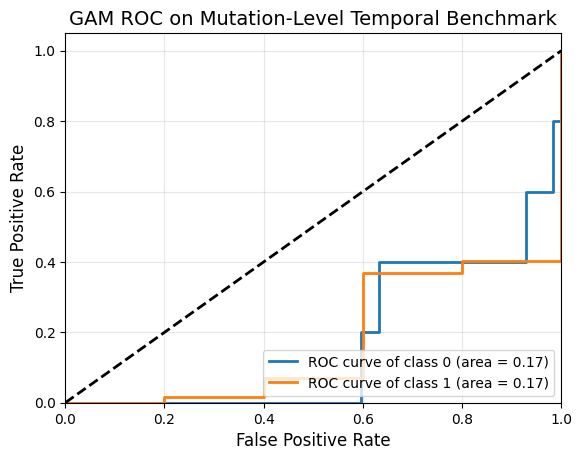

In [73]:
# ROC / AUC for GAM on the mutation-level temporal evaluation set
unique_classes = sorted(np.unique(y_train_split))
print("Unique classes:", unique_classes)

if y_prob_cat3_gam.ndim == 1:
    y_prob_cat3_gam = np.column_stack([1 - y_prob_cat3_gam, y_prob_cat3_gam])
elif y_prob_cat3_gam.shape[1] == 1:
    y_prob_cat3_gam = y_prob_cat3_gam.squeeze(axis=1)
    y_prob_cat3_gam = np.column_stack([1 - y_prob_cat3_gam, y_prob_cat3_gam])

print("Number of prediction columns in y_prob_cat3_gam:", y_prob_cat3_gam.shape[1])
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}
fpr_cat3_gam = {}
tpr_cat3_gam = {}
roc_auc_cat3_gam = {}

for cls in unique_classes:
    idx = class_to_index[cls]
    fpr_cat3_gam[cls], tpr_cat3_gam[cls], _ = roc_curve(y_true_cat3 == cls, y_prob_cat3_gam[:, idx])
    roc_auc_cat3_gam[cls] = auc(fpr_cat3_gam[cls], tpr_cat3_gam[cls])
    print(f"Class {cls}, AUC = {roc_auc_cat3_gam[cls]:.2f}")

plt.figure()
for cls in unique_classes:
    plt.plot(fpr_cat3_gam[cls], tpr_cat3_gam[cls], lw=2, label=f"ROC curve of class {cls} (area = {roc_auc_cat3_gam[cls]:0.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('GAM ROC on Mutation-Level Temporal Benchmark', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()


In [76]:
tn, fp, fn, tp = confusion_matrix(y_true_cat3, y_pred_cat3_gam).ravel()

type_1_error_gam = fp / (fp + tn)
type_2_error_gam = fn / (fn + tp)

print(f"GAM Type I Error (False Positive Rate): {type_1_error_gam:.4f}")
print(f"GAM Type II Error (False Negative Rate): {type_2_error_gam:.4f}")


GAM Type I Error (False Positive Rate): 0.4000
GAM Type II Error (False Negative Rate): 0.9825


Unique classes: [0, 1]
Class 0 AUC: 0.25
Class 1 AUC: 0.25


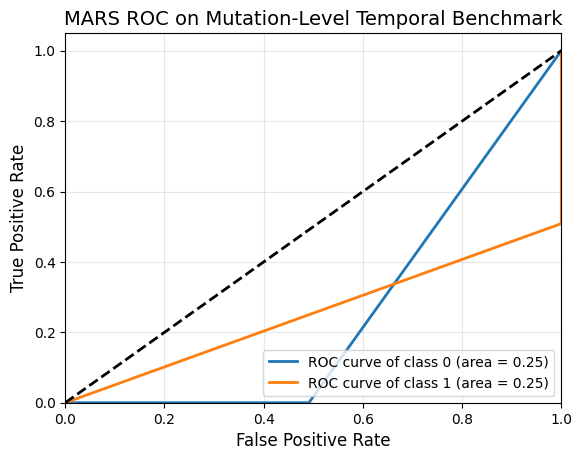

In [79]:
# Predict on the mutation-level temporal evaluation set with MARS
predict = ro.r['predict']
y_pred_response_mars_cat3 = np.array(predict(mars_model, X_category_3, type="class"))
y_test_pred_mars_cat3 = y_pred_response_mars_cat3.copy()

y_prob_cat3_mars = np.column_stack([1 - y_pred_response_mars_cat3, y_pred_response_mars_cat3])
unique_classes = sorted(np.unique(y_train_split))
print("Unique classes:", unique_classes)

class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}
fpr_cat3_mars = {}
tpr_cat3_mars = {}
roc_auc_cat3_mars = {}
for cls in unique_classes:
    idx = class_to_index[cls]
    fpr_cat3_mars[cls], tpr_cat3_mars[cls], _ = roc_curve(y_true_cat3 == cls, y_prob_cat3_mars[:, idx])
    roc_auc_cat3_mars[cls] = auc(fpr_cat3_mars[cls], tpr_cat3_mars[cls])
    print(f"Class {cls} AUC: {roc_auc_cat3_mars[cls]:.2f}")

plt.figure()
for cls in unique_classes:
    plt.plot(fpr_cat3_mars[cls], tpr_cat3_mars[cls], lw=2, label=f"ROC curve of class {cls} (area = {roc_auc_cat3_mars[cls]:0.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('MARS ROC on Mutation-Level Temporal Benchmark', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.85      0.51      0.64        57

    accuracy                           0.47        62
   macro avg       0.43      0.25      0.32        62
weighted avg       0.78      0.47      0.59        62



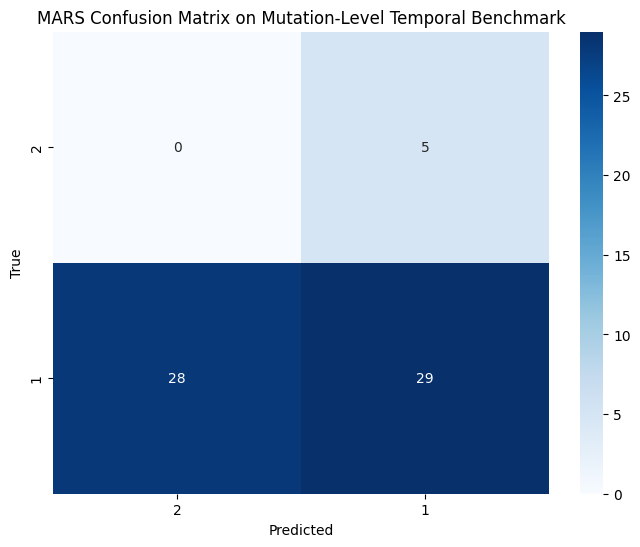

0.46774193548387094


In [80]:
print(classification_report(y_true_cat3, y_test_pred_mars_cat3))
cm = confusion_matrix(y_true_cat3, y_test_pred_mars_cat3)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[2, 1], yticklabels=[2, 1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MARS Confusion Matrix on Mutation-Level Temporal Benchmark")
plt.show()

print(accuracy_score(y_true_cat3, y_test_pred_mars_cat3))


In [81]:
tn, fp, fn, tp = confusion_matrix(y_true_cat3, y_test_pred_mars_cat3).ravel()

type_1_error_mars = fp / (fp + tn)
type_2_error_mars = fn / (fn + tp)

print(f"MARS Type I Error (False Positive Rate): {type_1_error_mars:.4f}")
print(f"MARS Type II Error (False Negative Rate): {type_2_error_mars:.4f}")


MARS Type I Error (False Positive Rate): 1.0000
MARS Type II Error (False Negative Rate): 0.4912
